In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plumed
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np

In [2]:
def search_contacts(df, chain, resi):
    search = rf"^{chain}:.*:{resi}$"
    mask = df.astype(str).apply(
        lambda col: col.str.contains(search, regex=True, na=False)
    ).any(axis=1)
    return df[mask]
def plot_contacts(df):
    plt.figure(figsize=(10, 6))
    for col in df.columns:
        plt.plot(df.index, df[col], label=f'Column {col}')
    plt.xlabel('Frame')
    plt.ylabel('Contact Value')
    plt.title('Contact Values Over Time')
    plt.legend()
    plt.show()

##### 查找单个氨基酸

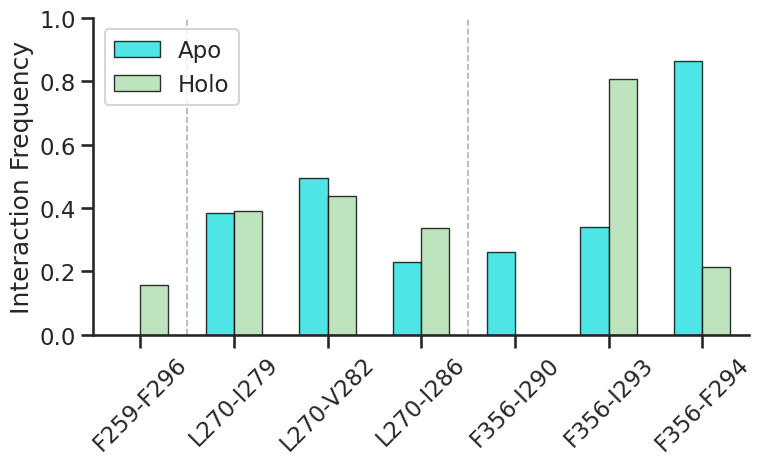

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. 配置参数 ---
base_path = '/workdir/AgOR10_28/AgOR10/'
itype = 'hp'
state_order = ["Apo", "Holo"]

colors = {
    "Apo": (0.0, 1.0, 1.0),        # #00FFFF
    "Holo": (0.65, 0.9, 0.65)  # #A6E6A6
}
# 残基映射表
res_map = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

targets = [
    {"search": "A:PHE:259", "exclude": "66|67|289|293|359", "label": "F259"},
    {"search": "A:LEU:270", "exclude": "367", "label": "L270"},        
    {"search": "A:PHE:356", "exclude": "353|360", "label": "F356"}          
]

paths = {
    "Apo": f"{base_path}AgOR10_apo/cuts1/protein_{itype}.tsv",
    "Holo": f"{base_path}AgOR10_bound/protein_{itype}.tsv"
}

all_processed_data = []

def get_short_name(res_str):
    """A:PHE:356 -> F356"""
    try:
        parts = res_str.replace("A:", "").split(":")
        return f"{res_map.get(parts[0], parts[0])}{parts[1]}"
    except:
        return res_str

for target in targets:
    for state, path in paths.items():
        try:
            df = pd.read_csv(path, sep='\t', skiprows=2, header=None)
            search = target["search"]
            df_sub = df[(df[0] == search) | (df[1] == search)].copy()
            df_sub["partner"] = df_sub.apply(lambda row: row[1] if row[0] == search else row[0], axis=1)
            df_sub = df_sub[~df_sub["partner"].str.startswith("D:")]
            df_sub = df_sub[~df_sub["partner"].str.contains(target["exclude"])]
            
            df_sub["partner_short"] = df_sub["partner"].apply(get_short_name)
            df_sub["display_name"] = target["label"] + "-" + df_sub["partner_short"]
            df_sub['res_num'] = df_sub['partner'].str.extract('(\d+)').astype(int)
            df_sub["State"] = state
            df_sub["Target_Group"] = target["label"]
            
            df_sub = df_sub[df_sub[2] > 0.1]
            all_processed_data.append(df_sub)
        except:
            continue

df_final = pd.concat(all_processed_data)

target_order = [t["label"] for t in targets]
df_final["Target_Group"] = pd.Categorical(df_final["Target_Group"], categories=target_order, ordered=True)

df_final = df_final.sort_values(by=['Target_Group', 'res_num'])

ordered_display_names = df_final["display_name"].unique()
df_final["display_name"] = pd.Categorical(df_final["display_name"], categories=ordered_display_names, ordered=True)

num_x_ticks = len(ordered_display_names)
dynamic_width = max(8, num_x_ticks * 0.6 + 2) 
fig, ax = plt.subplots(figsize=(dynamic_width, 5))
sns.set_theme(style="ticks", context="talk")

sns.barplot(
    data=df_final, x="display_name", y=2, hue="State", 
    hue_order=state_order, palette=colors, 
    width=0.6, edgecolor="black", linewidth=1, ax=ax,alpha=0.8
)

current_pos = -0.5
for t_label in target_order[:-1]:
    group_count = df_final[df_final["Target_Group"] == t_label]["display_name"].nunique()
    if group_count > 0:
        current_pos += group_count
        ax.axvline(x=current_pos, color='black', linestyle='--', linewidth=1.2, alpha=0.3)


ax.set_ylim(0, 1)
ax.set_ylabel("Interaction Frequency")
ax.set_xlabel("")
ax.legend()
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.savefig('Merged_Final_Ordered.pdf', dpi=300)
plt.show()

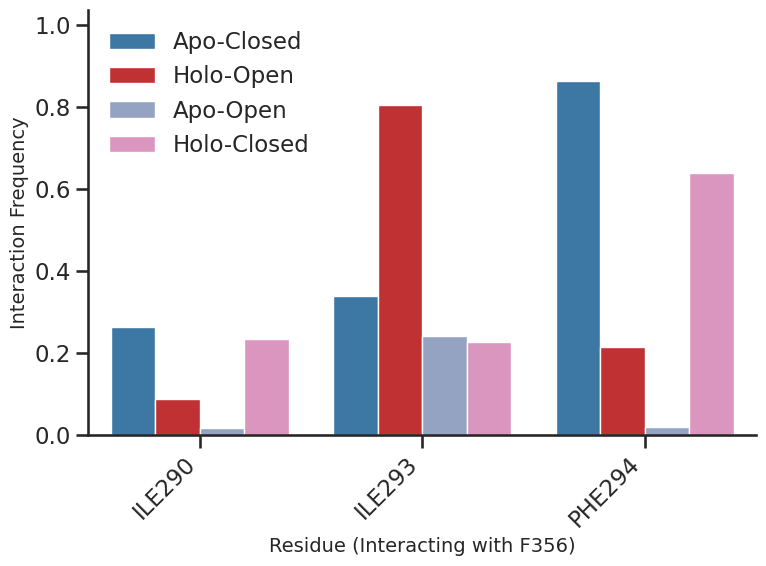

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

search = "A:PHE:356"
itype = 'hp'
base_path = '/workdir/AgOR10_28/AgOR10/'
paths = {
    "Apo-Closed": f"{base_path}AgOR10_apo/cuts1/protein_{itype}.tsv",
    "Holo-Open": f"{base_path}AgOR10_bound/protein_{itype}.tsv",
    "Apo-Open": f"{base_path}AgOR10_apo_open/protein_{itype}.tsv",
    "Holo-Closed": f"{base_path}AgOR10_bound_close/protein_{itype}.tsv"
}

all_data = []

for state, path in paths.items():
    df = pd.read_csv(path, sep='\t', skiprows=2, header=None)

    df_sub = df[(df[0] == search) | (df[1] == search)].copy()

    df_sub["partner"] = df_sub.apply(
        lambda row: row[1] if row[0] == search else row[0], axis=1
    )

    df_sub = df_sub[~df_sub["partner"].str.startswith("D:")]
    df_sub = df_sub[~df_sub["partner"].str.contains("59|60|269|353|356|298")] # 使用正则合并排除

    df_sub["partner_short"] = df_sub["partner"].str.replace("A:", "", regex=False)
    df_sub["partner_short"] = df_sub["partner_short"].str.replace(":", "")

    df_sub['res_num'] = df_sub['partner_short'].str.extract('(\d+)').astype(int)

    df_sub["State"] = state

    df_sub = df_sub[df_sub[2] > 0]
    all_data.append(df_sub)

df_combined = pd.concat(all_data).sort_values(by='res_num')

sns.set_theme(style="ticks", context="talk")
plt.figure(figsize=(8, 6))

colors = {"Apo-Closed": '#2C7BB6',"Apo-Open": '#8DA0CB', "Holo-Open": '#D7191C',  "Holo-Closed": '#E78AC3'}

ax = sns.barplot(
    x="partner_short", 
    y=2, 
    hue="State",
    data=df_combined, 
    palette=colors,
    edgecolor="white",
    linewidth=1
)

unique_partners = df_combined['partner_short'].unique()
y_max = df_combined[2].max()

sns.despine()
plt.xlabel("Residue (Interacting with F356)", fontsize=14)
plt.ylabel("Interaction Frequency", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.legend( frameon=False) 

plt.ylim(0, y_max * 1.2)

plt.tight_layout()
plt.savefig('F356_Apo_vs_Bound.pdf', dpi=300)
plt.show()

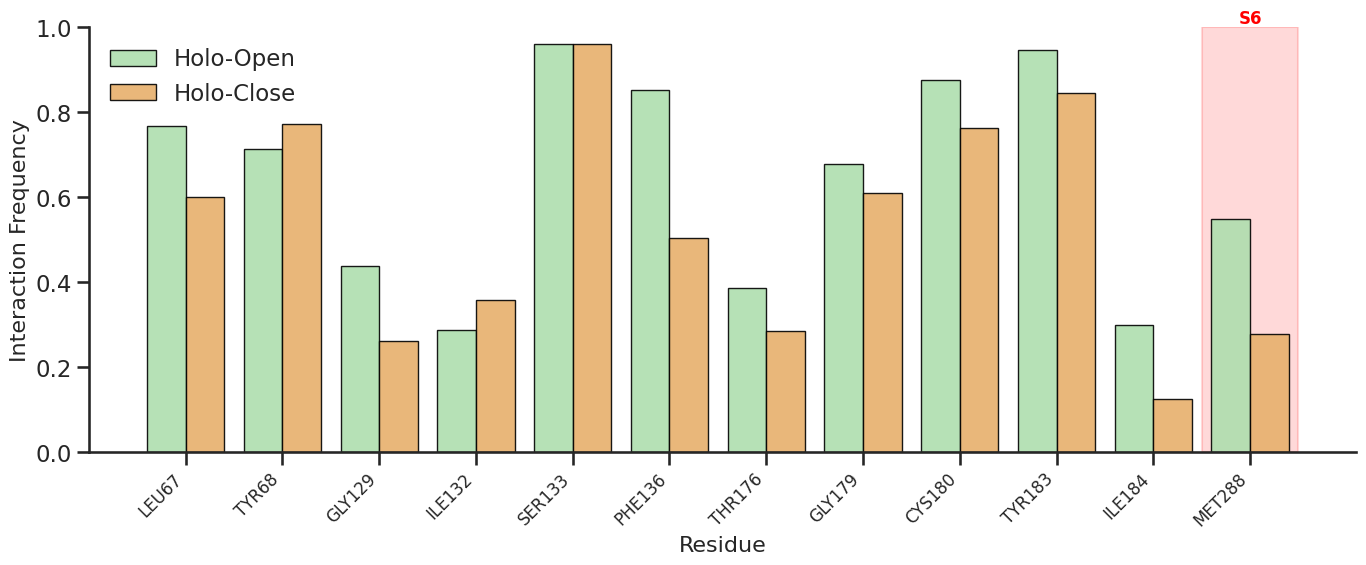

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches 

def get_processed_df(file_path, search_term, label):
    df = pd.read_csv(file_path, sep='\t', skiprows=2, header=None)
    df_sub = df[(df[0] == search_term) | (df[1] == search_term)].copy()
    df_sub["partner"] = df_sub.apply(
        lambda row: row[1] if row[0] == search_term else row[0], axis=1
    )

    df_sub["partner_short"] = df_sub["partner"].str.replace(r'^[A-Z]:', '', regex=True).str.replace(":", "")
    df_sub = df_sub[df_sub[2] > 0.1]
    df_sub['res_num'] = df_sub['partner_short'].str.extract('(\d+)').astype(int)
    res_df = df_sub[['partner_short', 'res_num', 2]].copy()
    res_df.columns = ['Residue', 'res_num', 'Frequency']
    res_df['Ligand'] = label
    return res_df

df1 = get_processed_df('/workdir/AgOR10_28/AgOR10/AgOR10_bound/MD_vdw.tsv', 'X:JZ0:1', 'Holo-Open')
df2 = get_processed_df('/workdir/AgOR10_28/AgOR10/AgOR10_bound_close/MD_vdw.tsv', 'E:JZ0:475', 'Holo-Close')
df_all = pd.concat([df1, df2]).sort_values(by='res_num')


sns.set_theme(style="ticks", context="talk")
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_all,
    x="Residue",
    y="Frequency",
    hue="Ligand",
    palette={"Holo-Open": "#A6E6A6", "Holo-Close": "#fcb257ff"},
    edgecolor="black",
    linewidth=1,
    alpha=0.9 
)


unique_residues = df_all['Residue'].unique().tolist()
y_max = df_all['Frequency'].max()

highlight_res_num = 288

try:
    target_idx = [i for i, res in enumerate(unique_residues) 
                   if int(''.join(filter(str.isdigit, res))) == highlight_res_num][0]

    plt.axvspan(target_idx - 0.5, target_idx + 0.5, color='red', alpha=0.15, zorder=0)
    plt.text(target_idx, y_max * 1.05, f"S6", ha='center', color='red', fontweight='bold', fontsize=12)

except IndexError:
    print(f"Residue {highlight_res_num} not found in the filtered data.")

groups = [
    {"label": "S2", "start_res": 215, "end_res": 218},
    {"label": "S3", "start_res": 230, "end_res": 240},
    {"label": "S4", "start_res": 250, "end_res": 265},
    {"label": "S6", "start_res": 470, "end_res": 480}
]

for g in groups:
    indices = [i for i, res in enumerate(unique_residues) 
               if g["start_res"] <= int(''.join(filter(str.isdigit, res))) <= g["end_res"]]
    if indices:
        start_idx, end_idx = min(indices), max(indices)
        mid_point = (start_idx + end_idx) / 2
        plt.text(mid_point, y_max * 1.18, g["label"], ha='center', va='bottom', fontsize=14, fontweight='bold')
        if start_idx != end_idx:
            plt.hlines(y_max * 1.16, start_idx-0.3, end_idx+0.3, colors='0.5', lw=1.5)

sns.despine()
plt.xlabel("Residue", fontsize=16)
plt.ylabel("Interaction Frequency", fontsize=16)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.legend( frameon=False)

plt.ylim(0, 1.0)

plt.tight_layout()
plt.savefig('ligand_comparison_highlighted.pdf', dpi=300)
plt.show()

In [ ]:
as_data = []
as_traj = []
for i in range(0,117):
    load = plumed.read_as_pandas(f'apo_from_bound/traj/COLVAR_tica{i}')
    load = load.drop(columns=['time'])
    columns = list(load.columns.values)

    for column in columns:
        if column[2:5] == 'phi' or column[2:5] == 'psi' or column[2:5] == 'chi' or column[2:7] == 'omega':
            load = load.drop(columns=[column])
    if len(load) > 1.6*20:
        as_traj.append(load)

    for i in range(len(as_traj)):
        numpy_data = as_traj[i].to_numpy(dtype='float32')
        as_data.append(numpy_data)
tica_output_concat = np.concatenate(as_data, axis=0)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


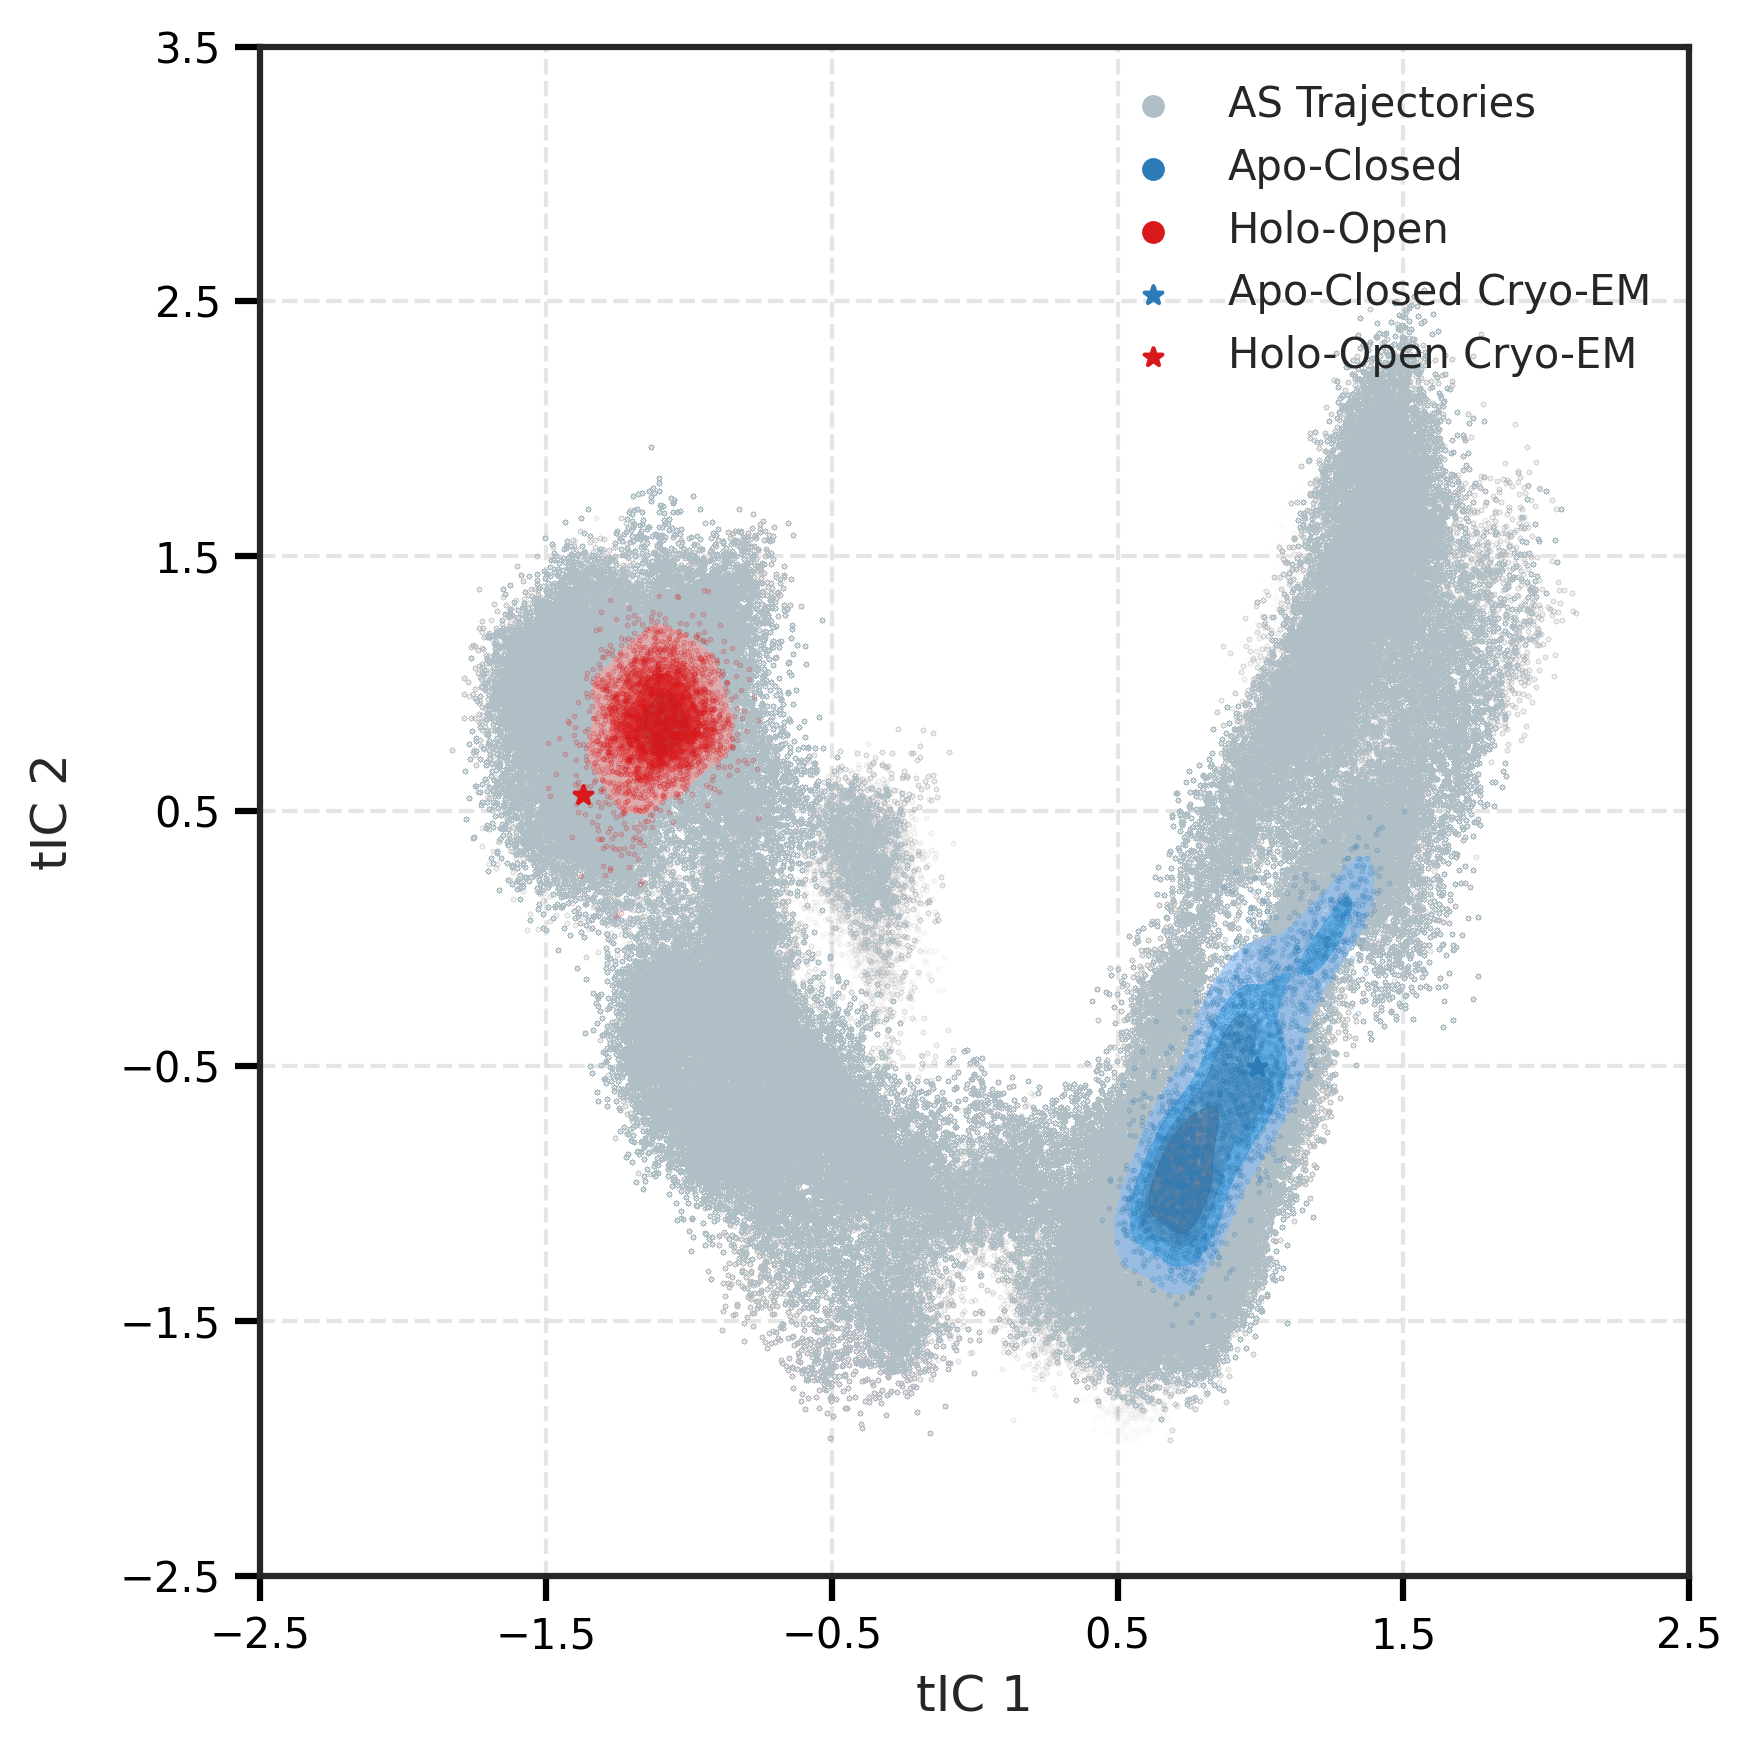

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
apo_data = plumed.read_as_pandas("AgOR10_apo/cuts1/COLVAR_tica")
bound_data = plumed.read_as_pandas("AgOR10_bound/COLVAR_tica")
apo_data_start = plumed.read_as_pandas("AgOR10_apo/cuts1/COLVAR_tica_start")
bound_data_start = plumed.read_as_pandas("AgOR10_bound/COLVAR_tica_start")
import seaborn as sns
import matplotlib.pyplot as plt

# 设置基础风格
sns.set_style("white") 
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

colors = {'apo': '#00FFFF', 'holo': '#A6E6A6'}
ax.scatter(tica_output_concat[:,0], tica_output_concat[:,1], 
           s=0.1, alpha=0.01, c='#B0BEC5', label='AS Trajectories', rasterized=True)
sns.kdeplot(x=apo_data['tica0'], y=apo_data['tica1'], 
            color=colors['apo'], fill=True, thresh=0.1, alpha=0.7, levels=5, ax=ax)
sns.kdeplot(x=bound_data['tica0'], y=bound_data['tica1'], 
            color=colors['holo'], fill=True, thresh=0.1, alpha=0.7, levels=5, ax=ax)

ax.scatter(apo_data['tica0'], apo_data['tica1'], 
           s=0.1, alpha=0.3, label='Apo-Closed', c=colors['apo'], rasterized=True)
ax.scatter(bound_data['tica0'], bound_data['tica1'], 
           s=0.1, alpha=0.3, label='Holo-Open', c=colors['holo'], rasterized=True)
ax.scatter(apo_data_start['tica0'][:1], apo_data_start['tica1'][:1], 
           s=20, alpha=1, marker='*',label='Apo-Closed Cryo-EM', c='red')
ax.scatter(bound_data_start['tica0'][:1], bound_data_start['tica1'][:1], 
           s=20, alpha=1, marker='*',label='Holo-Open Cryo-EM', c='black')
xmin, xmax = -2.5, 2.5
ymin, ymax = -2.5, 3.5

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='both', which='major', direction='out', length=6, width=1.5, colors='black')

ax.set_xlim(xmin, xmax) 
ax.set_ylim(ymin, ymax)
ax.set_xticks(np.arange(xmin, xmax+0.1, 1))
ax.set_yticks(np.arange(ymin, ymax+0.1, 1))

ax.set_xlabel('tIC 1',fontsize=12)
ax.set_ylabel('tIC 2',fontsize=12, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=10, width=1.5)
# 图例优化
leg = ax.legend(loc='upper right', markerscale=8, frameon=False,fontsize=10)
for handle in leg.legend_handles:
    handle.set_sizes([20]) 
    handle.set_alpha(1)


plt.tight_layout()
plt.savefig('tica_with_arrows.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


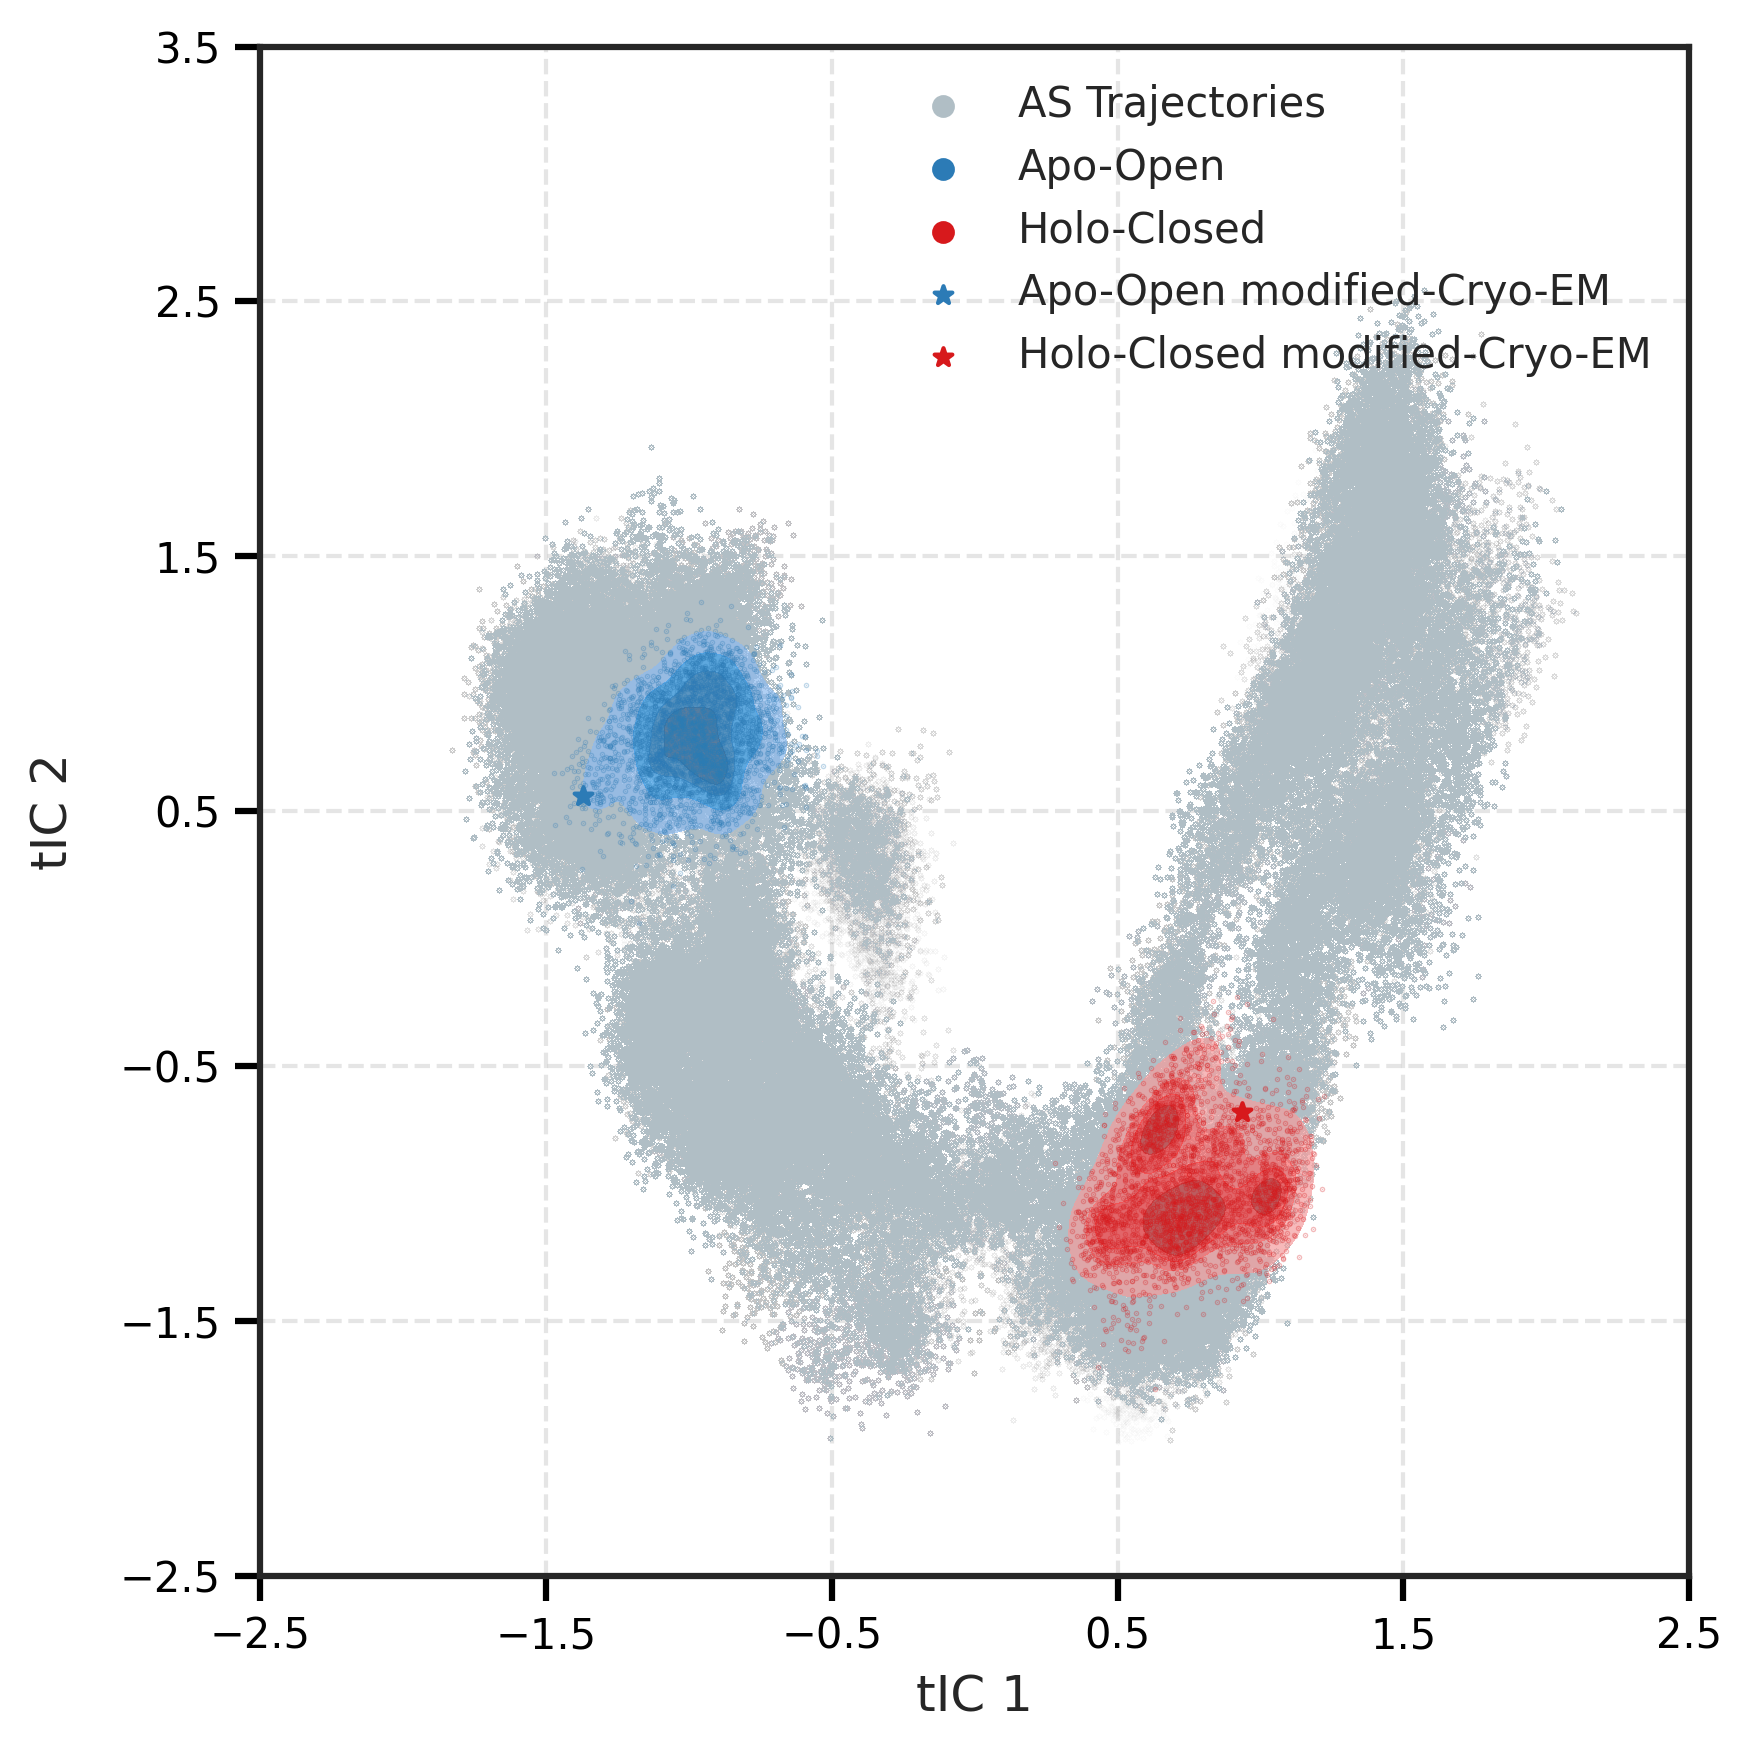

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
apo_data = plumed.read_as_pandas("AgOR10_apo_open/COLVAR_tica")
bound_data = plumed.read_as_pandas("AgOR10_bound_close/COLVAR_tica")
apo_data_start = plumed.read_as_pandas("AgOR10_apo_open/COLVAR_tica_start")
bound_data_start = plumed.read_as_pandas("AgOR10_bound_close/COLVAR_tica_start")
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white") 
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

colors = {'apo': '#00FFFF', 'holo': '#A6E6A6'}
ax.scatter(tica_output_concat[:,0], tica_output_concat[:,1], 
           s=0.1, alpha=0.01, c='#B0BEC5', label='AS Trajectories', rasterized=True)

sns.kdeplot(x=apo_data['tica0'], y=apo_data['tica1'], 
            color=colors['apo'], fill=True, thresh=0.1, alpha=0.7, levels=5, ax=ax)
sns.kdeplot(x=bound_data['tica0'], y=bound_data['tica1'], 
            color=colors['holo'], fill=True, thresh=0.1, alpha=0.7, levels=5, ax=ax)

ax.scatter(apo_data['tica0'], apo_data['tica1'], 
           s=0.1, alpha=0.3, label='Apo-Open', c=colors['apo'], rasterized=True)
ax.scatter(bound_data['tica0'], bound_data['tica1'], 
           s=0.1, alpha=0.3, label='Holo-Closed', c=colors['holo'], rasterized=True)


ax.scatter(apo_data_start['tica0'][:1], apo_data_start['tica1'][:1], 
           s=20, alpha=1, marker='*',label='Apo-Open modified-Cryo-EM', c='red')
ax.scatter(bound_data_start['tica0'][:1], bound_data_start['tica1'][:1], 
           s=20, alpha=1, marker='*',label='Holo-Closed modified-Cryo-EM', c='black')

xmin, xmax = -2.5, 2.5
ymin, ymax = -2.5, 3.5


ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='both', which='major', direction='out', length=6, width=1.5, colors='black')

ax.set_xlim(xmin, xmax) 
ax.set_ylim(ymin, ymax)
ax.set_xticks(np.arange(xmin, xmax+0.1, 1))
ax.set_yticks(np.arange(ymin, ymax+0.1, 1))

ax.set_xlabel('tIC 1',fontsize=12) 
ax.set_ylabel('tIC 2',fontsize=12, labelpad=10)

ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=10, width=1.5)

leg = ax.legend(loc='upper right', markerscale=8, frameon=False,fontsize=10)
for handle in leg.legend_handles:
    handle.set_sizes([20])
    handle.set_alpha(1)

plt.tight_layout()
plt.savefig('tica_with_arrows_twonew.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


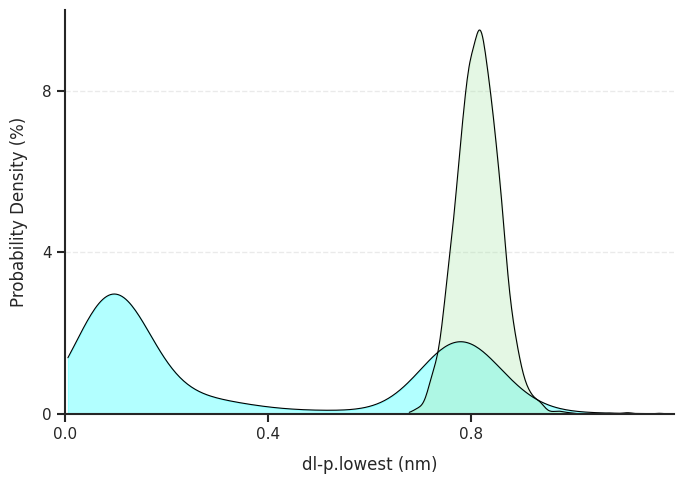

In [ ]:
sns.set_theme(style="ticks")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300) 
    return x_range, kde(x_range)

datasets = [
    {'path': 'AgOR10_apo/cuts1/COLVAR_lipid', 'label': 'Apo-Closed State', 'color':  '#00FFFF'}, 
    {'path': 'AgOR10_bound/COLVAR_lipid', 'label': 'Holo-Open State', 'color': '#A6E6A6'} 
]

fig, ax = plt.subplots(figsize=(7, 5))

for ds in datasets:
    x, y = get_kde_data(ds['path'], 'dl-p.lowest')

    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2, zorder=2)
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

ax.set_xlabel('dl-p.lowest (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)
sns.despine()

ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.set_xlim(0,1.2)
ax.set_xticks(np.arange(0,1.2,0.4))
ax.set_ylim(0,10)
ax.set_yticks(np.arange(0,10,4))
plt.tight_layout()
plt.savefig('lipid_distribution_comparison.pdf', dpi=300, transparent=True)
plt.show()
    


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


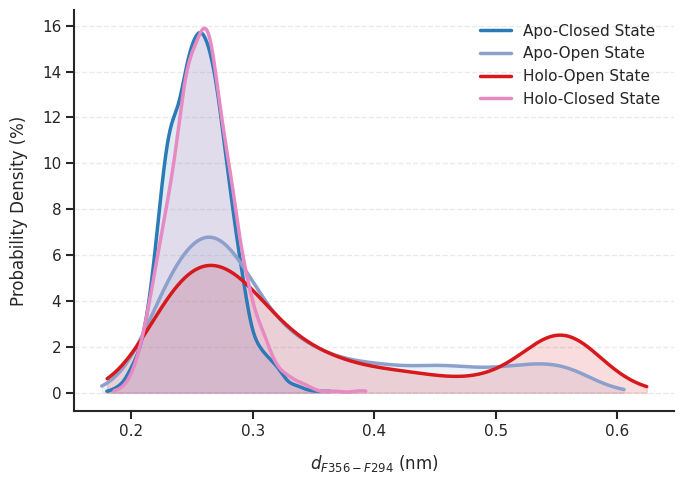

In [ ]:
sns.set_theme(style="ticks") 
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300)
    return x_range, kde(x_range)

datasets = [
    {'path': 'AgOR10_apo/cuts1/COLVAR_S6-S7', 'label': 'Apo-Closed State', 'color': '#2C7BB6'}, 
    {'path': 'AgOR10_apo_open/COLVAR_S6-S7', 'label': 'Apo-Open State', 'color': '#8DA0CB'},
    {'path': 'AgOR10_bound/COLVAR_S6-S7', 'label': 'Holo-Open State', 'color': '#D7191C'}, 
    {'path': 'AgOR10_bound_close/COLVAR_S6-S7', 'label': 'Holo-Closed State', 'color': '#E78AC3'} 
]


fig, ax = plt.subplots(figsize=(7, 5))

for ds in datasets:
    x, y = get_kde_data(ds['path'], 'd_A_PHE356_A_PHE294.min')

    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2.5, zorder=2)
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

ax.set_xlabel(r'$d_{F356-F294}$ (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)
sns.despine()

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('dF356-F294.pdf', dpi=300, transparent=True)
plt.show()
    


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


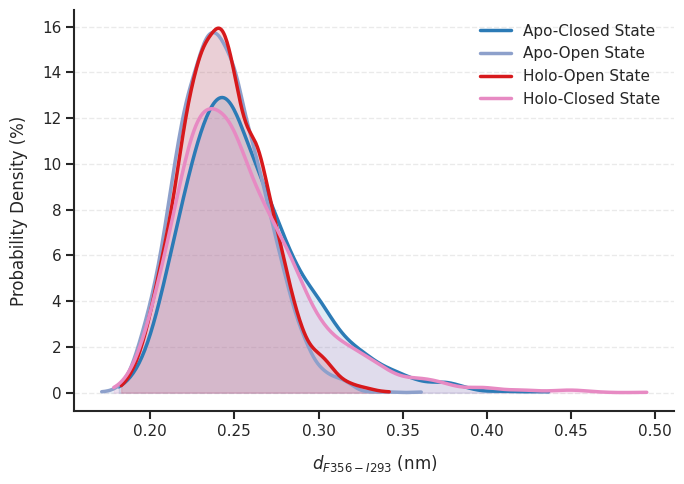

In [ ]:
sns.set_theme(style="ticks") 
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300)
    return x_range, kde(x_range)

datasets = [
    {'path': 'AgOR10_apo/cuts1/COLVAR_S6-S7', 'label': 'Apo-Closed State', 'color': '#2C7BB6'}, 
    {'path': 'AgOR10_apo_open/COLVAR_S6-S7', 'label': 'Apo-Open State', 'color': '#8DA0CB'},
    {'path': 'AgOR10_bound/COLVAR_S6-S7', 'label': 'Holo-Open State', 'color': '#D7191C'}, 
    {'path': 'AgOR10_bound_close/COLVAR_S6-S7', 'label': 'Holo-Closed State', 'color': '#E78AC3'} 
]

fig, ax = plt.subplots(figsize=(7, 5))

for ds in datasets:
    x, y = get_kde_data(ds['path'], 'd_A_PHE356_A_ILE293.min')
    
    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2.5, zorder=2)
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

ax.set_xlabel(r'$d_{F356-I293}$ (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)

sns.despine()

ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('dF356-F293.pdf', dpi=300, transparent=True)
plt.show()
    


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


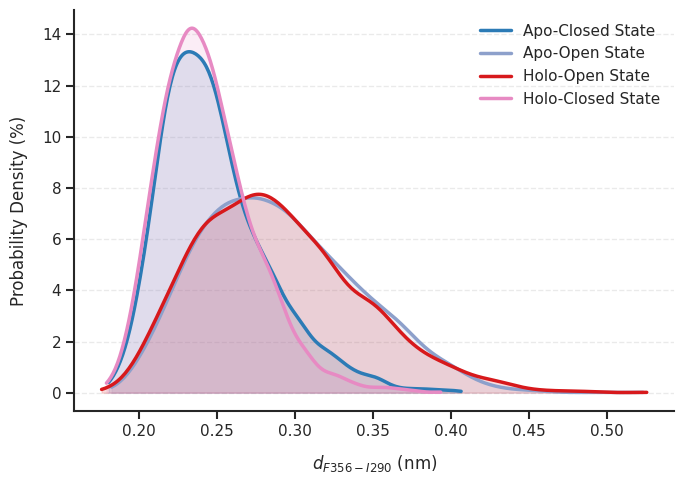

In [ ]:
sns.set_theme(style="ticks")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300) 
    return x_range, kde(x_range)


datasets = [
    {'path': 'AgOR10_apo/cuts1/COLVAR_S6-S7', 'label': 'Apo-Closed State', 'color': '#2C7BB6'},
    {'path': 'AgOR10_apo_open/COLVAR_S6-S7', 'label': 'Apo-Open State', 'color': '#8DA0CB'}, 
    {'path': 'AgOR10_bound/COLVAR_S6-S7', 'label': 'Holo-Open State', 'color': '#D7191C'}, 
    {'path': 'AgOR10_bound_close/COLVAR_S6-S7', 'label': 'Holo-Closed State', 'color': '#E78AC3'} 
]

fig, ax = plt.subplots(figsize=(7, 5))

for ds in datasets:
    x, y = get_kde_data(ds['path'], 'd_A_PHE356_A_ILE290.min')
    
    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2.5, zorder=2)

    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

ax.set_xlabel(r'$d_{F356-I290}$ (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)

sns.despine()

ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('dF356-I290.pdf', dpi=300, transparent=True)
plt.show()
    


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


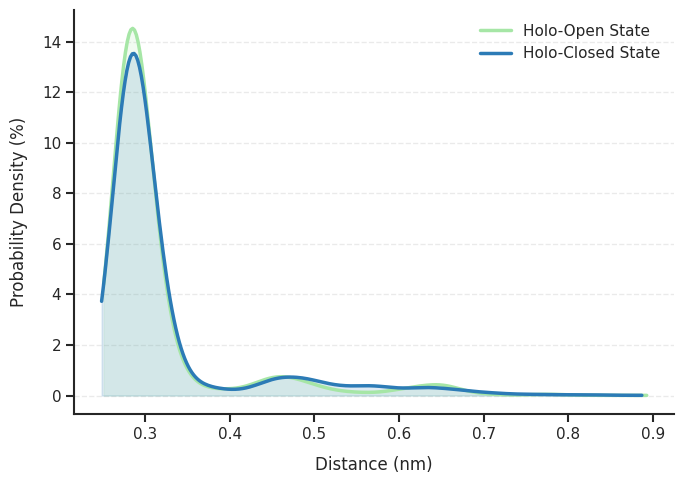

In [ ]:
sns.set_theme(style="ticks") 
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5
})

def get_kde_data(file_path, column_name):
    data = plumed.read_as_pandas(file_path)
    values = data[column_name].values
    kde = gaussian_kde(values)
    x_range = np.linspace(np.min(values), np.max(values), 300) 
    return x_range, kde(x_range)

datasets = [
    {'path': 'AgOR10_bound/COLVAR_d-S133', 'label': 'Holo-Open State', 'color': '#D7191C'}, # 暖红色
    {'path': 'AgOR10_bound_close/COLVAR_d-S133', 'label': 'Holo-Closed State', 'color': '#2C7BB6'} # 深蓝色
]

fig, ax = plt.subplots(figsize=(7, 5))

for ds in datasets:
    x, y = get_kde_data(ds['path'], 'dl-S133')

    ax.plot(x, y, color=ds['color'], label=ds['label'], lw=2.5, zorder=2)
    ax.fill_between(x, y, color=ds['color'], alpha=0.15, zorder=1)

ax.set_xlabel('Distance (nm)', labelpad=10)
ax.set_ylabel('Probability Density (%)', labelpad=10)

sns.despine()

ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.legend(frameon=False, loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('dl-S133_comparison.pdf', dpi=300, transparent=True)
plt.show()
    


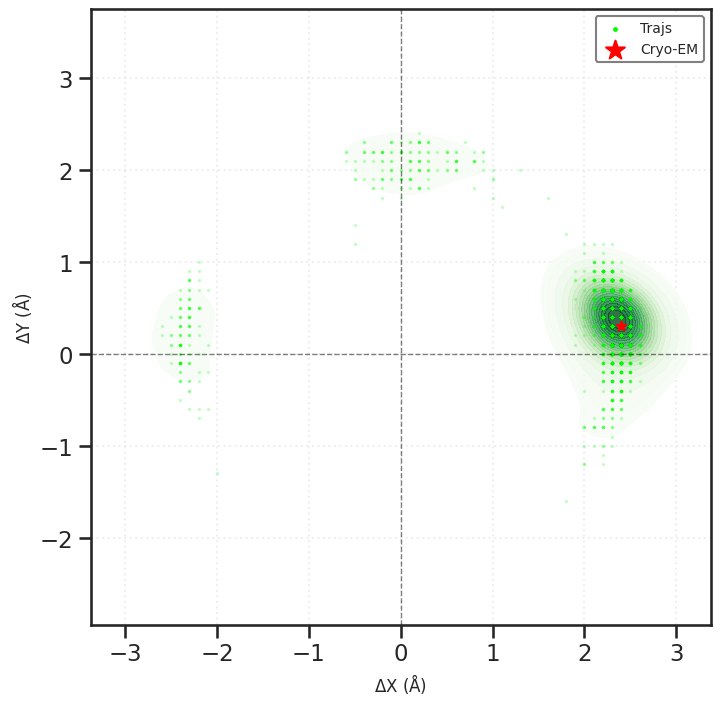

In [ ]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pdb_file = 'AgOR10_bound/ligand.pdb' 
selection1 = 'index 3' 
selection2 = 'index 1' 


u = mda.Universe(pdb_file)
atom_start = u.select_atoms(selection1)
atom_end = u.select_atoms(selection2)

vectors_xy = []
for ts in u.trajectory:
    vec_3d = atom_end.positions[0] - atom_start.positions[0]
    vectors_xy.append(vec_3d[:2]) 

vectors_xy = np.array(vectors_xy)
U = vectors_xy[:, 0]  
V = vectors_xy[:, 1] 

plt.figure(figsize=(8, 8))

sns.kdeplot(x=U, y=V, fill=True, thresh=0.05, levels=20, cmap="Greens", alpha=0.8)
plt.scatter(U, V, s=1, color='#00FF00', alpha=0.2, label='Trajs')
plt.scatter(U[0], V[0], color='red', s=50, marker='*', 
            zorder=10, label='Cryo-EM')

plt.axhline(0, color='black', linewidth=1, alpha=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=1, alpha=0.5, linestyle='--')

plt.xlabel('$\Delta$X (Å)', fontsize=12)
plt.ylabel('$\Delta$Y (Å)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.3)
leg = plt.legend(
    loc='upper right', 
    fontsize=10,            
    frameon=True,           
    framealpha=1,        
    edgecolor='gray',      
    markerscale=2.0,        
)
for lh in leg.legend_handles: 
    lh.set_alpha(1.0)
plt.axis('equal') 
plt.savefig('vector_density_plot.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

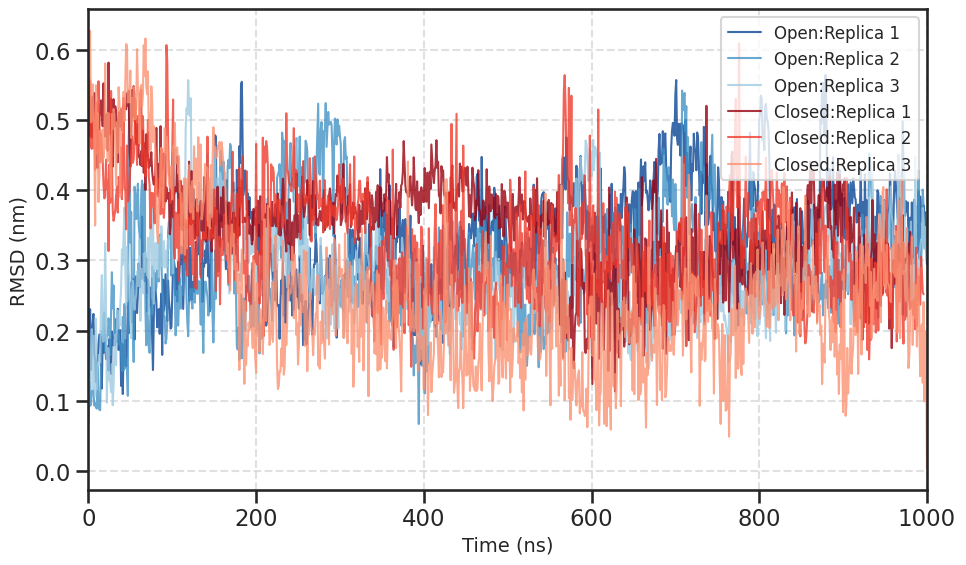

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

files = ['AgOR10_bound/rmsd1.xvg', 'AgOR10_bound/rmsd2.xvg', 'AgOR10_bound/rmsd3.xvg','AgOR10_bound_close/rmsd1.xvg', 'AgOR10_bound_close/rmsd2.xvg', 'AgOR10_bound_close/rmsd3.xvg']
labels = ['Open:Replica 1', 'Open:Replica 2', 'Open:Replica 3', 'Closed:Replica 1', 'Closed:Replica 2', 'Closed:Replica 3']
colors = [
    '#084594', '#4292c6', '#9ecae1',  
    '#99000d', '#ef3b2c', '#fc9272' 
]

plt.figure(figsize=(10, 6))

for file, label, color in zip(files, labels, colors):
   
    data = np.loadtxt(file, comments=['#', '@'])
    
    time = data[:, 0]/1000  
    rmsd = data[:, 1]  
    
    plt.plot(time, rmsd, label=label, color=color, linewidth=1.5, alpha=0.8)
plt.xlabel("Time (ns)", fontsize=14)
plt.ylabel("RMSD (nm)", fontsize=14)
plt.xlim(0,1000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=12)
plt.tight_layout()
plt.savefig('combined_rmsd.pdf', dpi=300)
plt.show()

134
Counter({'A': 31, 'S': 23, 'C': 18, 'V': 15, 'F': 10, 'G': 7, 'P': 6, 'T': 6, 'I': 6, 'L': 4, 'Y': 3, 'M': 3, 'N': 1})


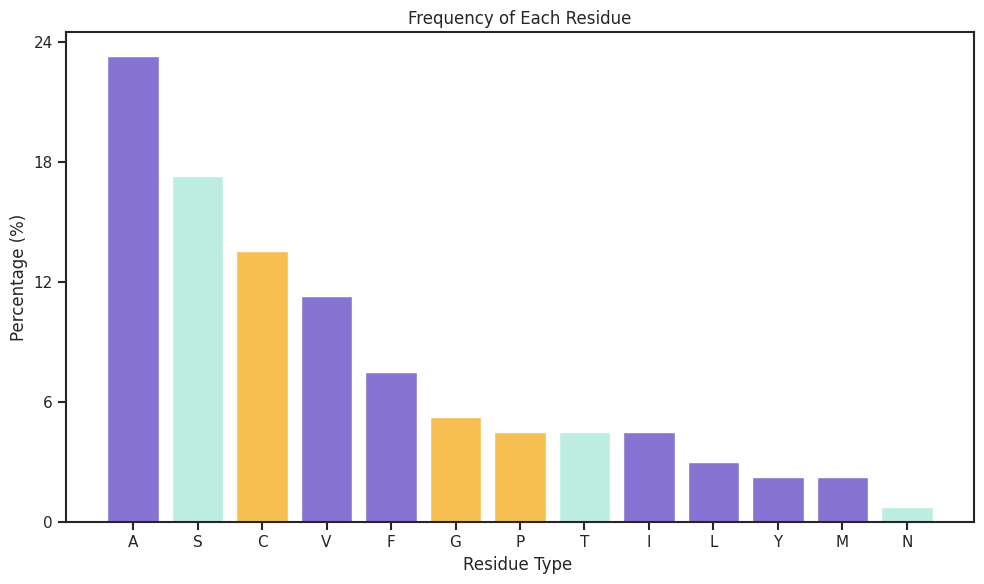

In [ ]:
msa_file = "S6.csv" #M288 1stM Q292 2ndQ F294 2ndF I293 4thI F296 3rdF S291 1stS
import pandas as pd
df = pd.read_csv(msa_file,sep=",",header=None)
msa = df.iloc[:,1]
print(len(msa))
ref_seq = msa[3]
query_seq = np.concatenate([msa[0:3].to_numpy(),msa[4:].to_numpy()])
p_positions = [[i for i, aa in enumerate(ref_seq) if aa == "S"][0]]
p_site_aas = [j[i] for i in p_positions for j in query_seq]
from collections import Counter
counts = Counter(p_site_aas)
print(counts)
sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
letters = [item[0] for item in sorted_items]
num = [item[1] for item in sorted_items]
letters = letters
num = num/ np.sum(num)*100
group1 = {'Q', 'S', 'N','T'}
group2 = {'C', 'G', 'P'}
group3 = {'R', 'H', 'K', 'D', 'E'}
group4 = {'A', 'V', 'L', 'I', 'M', 'F', 'Y', 'W'}
COLOR_GROUP1 = '#BDEDE0'  # muted blue
COLOR_GROUP2 = '#F6BF51'  # muted orange
COLOR_GROUP3 = '#C95D63'  # muted green
COLOR_OTHER  = '#8774D2'  # neutral gray

colors = []
for letter in letters:
    if letter in group1:
        colors.append(COLOR_GROUP1)
    elif letter in group2:
       colors.append(COLOR_GROUP2)
    elif letter in group3:
        colors.append(COLOR_GROUP3)
    elif letter in group4:
        colors.append(COLOR_OTHER)
        
plt.figure(figsize=(10, 6))
plt.bar(letters, num, color=colors,edgecolor='black',alpha=0.8,linewidth=1.2)
plt.xlabel('Residue Type ')
plt.ylabel('Percentage (%)')
plt.title('Frequency of Each Residue')
plt.yticks(np.arange(0, max(num)+3, 6))

plt.tight_layout()
plt.savefig('S_substitution_counts.pdf', dpi=300)
plt.show()